In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import igraph as ig
import cvxpy as cp

In [3]:
plt.rcParams["mathtext.fontset"] = "cm"
plt.rc('font', family='serif',size=10)
plt.rc('text', usetex=True)

In [4]:
def bound_condition(graph):
    num_edges = graph.ecount()
    ineq_matrix = np.zeros([2*num_edges, num_edges], dtype=np.int64)
    ineq_vector = np.ones(2*num_edges, dtype=np.int64)
    ineq_vector[::2] = 0

    for i in range(num_edges):
        ineq_matrix[2*i][i] = -1
        ineq_matrix[2*i + 1][i] = 1

    return ineq_matrix, ineq_vector

# assume start_nodes have zero in-degree, stop_nodes have zero out-degree
def kirchoff_law_condition(graph, start_nodes, stop_nodes):
    size = graph.vcount()
    num_edges = graph.ecount()
    num_conditions = size - len(start_nodes) - len(stop_nodes) + 2
    eq_matrix = np.zeros([num_conditions, num_edges], dtype=np.int64)
    eq_vector = np.zeros(num_conditions, dtype=np.int64)

    condition = np.zeros(num_edges, dtype=np.int64)
    for i in start_nodes:
        start_edges = graph.incident(i, mode='out')
        for edge in start_edges:
            condition[edge] = 1

    eq_matrix[0] = condition
    eq_vector[0] = 1

    all_nodes = [i for i in range(size)]
    regular_nodes = np.array([i for i in all_nodes if ((i not in start_nodes) and (i not in stop_nodes))])
    count = 1

    for i in regular_nodes:
        in_edges = graph.incident(i, mode='in')
        out_edges = graph.incident(i, mode='out')

        condition = np.zeros(num_edges, dtype=np.int64)
        for in_edge in in_edges:
            condition[in_edge] = -1
        for out_edge in out_edges:
            condition[out_edge] = 1
        
        eq_matrix[count] = condition
        eq_vector[count] = 0
        count += 1

    condition = np.zeros(num_edges, dtype=np.int64)
    for i in stop_nodes:
        stop_edges = graph.incident(i, mode='in')
        for edge in stop_edges:
            condition[edge] = 1

    eq_matrix[-1] = condition
    eq_vector[-1] = 1

    return eq_matrix, eq_vector

def quad_coeff(road_types):
    quad_matrix = np.zeros([len(road_types), len(road_types)], dtype=np.int64)
    
    for k in range(len(road_types)):
        quad_matrix[k][k] = road_types[k]

    return quad_matrix

def linear_coeff(road_types):
    linear_vector = np.zeros(len(road_types), dtype=np.int64)

    for k in range(len(road_types)):
        linear_vector[k] = (road_types[k] + 1) % 2

    return linear_vector

def assign_road_type(graph, p):
    num_edges = graph.ecount()
    
    road_types = np.zeros(num_edges, dtype=np.int64)
    for i in range(num_edges):
        if (random.random() < p):
            road_types[i] = 1

    return road_types

def commute_time(roads, road_types):
    commute = 0
    for k in range(len(roads)):
        if(road_types[k] == 0):
            commute += roads[k]
        else:
            commute += roads[k]**2
    
    return commute


Code for finding average path length for BA model

In [ ]:
N_vals = np.array([i for i in range(5, 50)])
avg_path_lengths = np.zeros_like(N_vals, dtype=np.float64)

for k in range(100):
    for i in range(5, 50):
        M = 2*i*(i+1)
        start = ig.Graph(directed=True)
        start.add_vertices(i)

        not_okay = True

        while(not_okay):
            ba_graph = ig.Graph.Barabasi(M, 2, directed=True, start_from=start)
            in_degrees = ba_graph.indegree()
            zero_in = [j for j, d in enumerate(in_degrees) if d == 0]
            out_degrees = ba_graph.outdegree()
            zero_out = [j for j, d in enumerate(out_degrees) if d == 0]

            if(len(set(zero_in).intersection(set(zero_out))) == 0):
                not_okay = False

        end_nodes = [j for j in range(i)]
        start_nodes = [ba_graph.vcount() - i + j for j in range(i)]

        avg_path = 0
        for v1 in start_nodes:
            min_path = 500000
            for v2 in end_nodes:
                path_length = len(ba_graph.get_shortest_path(v1, v2))
                if (path_length > 0 and path_length < min_path):
                    min_path = path_length
            
            avg_path += min_path
        
        avg_path = avg_path / i
        avg_path_lengths[i-5] += avg_path

avg_path_lengths = avg_path_lengths / 100

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.plot(N_vals, avg_path_lengths, color='black')
#ax.scatter(N_vals, connect_vals, color='black')

ax.set_ylabel("Average Distance", fontsize=15)
ax.set_xlabel("Number of Start Nodes", fontsize=15)
ax.set_title("Distance Between Start and End Nodes", fontsize=15)

ax.set_xlim(0, 50)
#ax.legend()
fig.tight_layout()

Different start node choice below: consider every pair of start nodes and average over.

In [ ]:
M = 50
not_okay = True

while(not_okay):
    ba_graph = ig.Graph.Barabasi(M, 2, directed=True)
    ba_copy = ba_graph.as_undirected()
    degrees = ba_copy.degree()
    degree_nums = [d for j, d in enumerate(degrees)]

    if(degree_nums[0] == max(degree_nums)):
        not_okay = False

p_vals = np.arange(0, 1.001, 0.05)

total_op_commute = np.zeros_like(p_vals)
total_eq_commute = np.zeros_like(p_vals)
R = 10

in_degrees = ba_graph.indegree()
start_nodes = [j for j, d in enumerate(in_degrees) if d == 0]
ineq_matrix, ineq_vector = bound_condition(ba_graph)

for i in range(R):
    print(i/R * 100)

    eq_commute_times = np.zeros_like(p_vals)
    op_commute_times = np.zeros_like(p_vals)

    for m in range(len(p_vals)):

        road_types = assign_road_type(ba_graph, p_vals[m])
        quadratic_coefficients = quad_coeff(road_types)
        linear_coefficients = linear_coeff(road_types)

        for l in range(len(start_nodes)):
            for k in range(l+1, len(start_nodes)):
                start_pair = [start_nodes[l], start_nodes[k]]

                eq_matrix, eq_vector = kirchoff_law_condition(ba_graph, start_pair, [0])

                x = cp.Variable(ba_graph.ecount())

                P = quadratic_coefficients
                q = linear_coefficients
                G = ineq_matrix
                h = ineq_vector
                A = eq_matrix
                b = eq_vector
                eq_prob = cp.Problem(cp.Minimize((1/2)*cp.quad_form(x, P) + q.T @ x),
                                [G @ x <= h,
                                A @ x == b])
                eq_prob.solve()

                sol = np.array(x.value)
                rounded_sol = np.where(sol < 0, 0, sol)

                eq_commute = commute_time(rounded_sol, road_types)

                y = cp.Variable(ba_graph.ecount())
                P = 2*P
                op_prob = cp.Problem(cp.Minimize((1/2)*cp.quad_form(y, P) + q.T @ y),
                                [G @ y <= h,
                                A @ y == b])
                op_prob.solve()

                sol = np.array(y.value)
                rounded_sol = np.where(sol < 0, 0, sol)

                op_commute = commute_time(rounded_sol, road_types)

                eq_commute_times[m] += eq_commute
                op_commute_times[m] += op_commute

        eq_commute_times[m] = eq_commute_times[m] / math.comb(len(start_nodes), 2)
        op_commute_times[m] = op_commute_times[m] / math.comb(len(start_nodes), 2)

    total_eq_commute += eq_commute_times
    total_op_commute += op_commute_times


avg_eq_commute = total_eq_commute / R
avg_op_commute = total_op_commute / R

The following code is to average over one choice of start node over all the start nodes.

In [ ]:
M = 50

p_vals = np.arange(0, 1.001, 0.05)
total_op_commute = np.zeros_like(p_vals)
total_eq_commute = np.zeros_like(p_vals)
R = 10

for i in range(R):
    print(i/R * 100)

    not_okay = True
    while(not_okay):
        ba_graph = ig.Graph.Barabasi(M, 2, directed=True)
        ba_copy = ba_graph.as_undirected()
        degrees = ba_copy.degree()
        degree_nums = [d for j, d in enumerate(degrees)]

        if(degree_nums[0] == max(degree_nums)):
            not_okay = False

    in_degrees = ba_graph.indegree()
    start_nodes = [j for j, d in enumerate(in_degrees) if d == 0]
    sampled_nodes = random.sample(start_nodes, int(len(start_nodes)/3))
    ineq_matrix, ineq_vector = bound_condition(ba_graph)

    eq_commute_times = np.zeros_like(p_vals)
    op_commute_times = np.zeros_like(p_vals)

    for m in range(len(p_vals)):

        road_types = assign_road_type(ba_graph, p_vals[m])
        quadratic_coefficients = quad_coeff(road_types)
        linear_coefficients = linear_coeff(road_types)

        for l in range(len(start_nodes)):
            eq_matrix, eq_vector = kirchoff_law_condition(ba_graph, [start_nodes[l]], [0])

            x = cp.Variable(ba_graph.ecount())

            P = quadratic_coefficients
            q = linear_coefficients
            G = ineq_matrix
            h = ineq_vector
            A = eq_matrix
            b = eq_vector
            eq_prob = cp.Problem(cp.Minimize((1/2)*cp.quad_form(x, P) + q.T @ x),
                            [G @ x <= h,
                            A @ x == b])
            eq_prob.solve()

            sol = np.array(x.value)
            rounded_sol = np.where(sol < 0, 0, sol)

            eq_commute = commute_time(rounded_sol, road_types)

            y = cp.Variable(ba_graph.ecount())
            P = 2*P
            op_prob = cp.Problem(cp.Minimize((1/2)*cp.quad_form(y, P) + q.T @ y),
                            [G @ y <= h,
                            A @ y == b])
            op_prob.solve()

            sol = np.array(y.value)
            rounded_sol = np.where(sol < 0, 0, sol)

            op_commute = commute_time(rounded_sol, road_types)

            eq_commute_times[m] += eq_commute
            op_commute_times[m] += op_commute

        eq_commute_times[m] = eq_commute_times[m] / len(start_nodes)
        op_commute_times[m] = op_commute_times[m] / len(start_nodes)

    total_eq_commute += eq_commute_times
    total_op_commute += op_commute_times


avg_eq_commute = total_eq_commute / R
avg_op_commute = total_op_commute / R

0.0
10.0
20.0
30.0
40.0
50.0
60.0
70.0
80.0
90.0


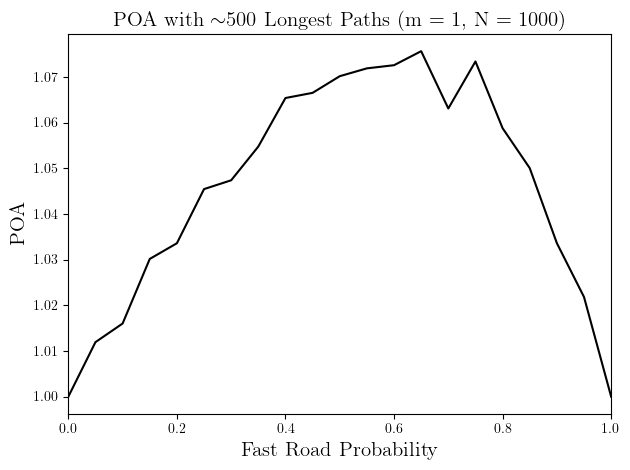

In [6]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

#ax.plot(p_vals, avg_eq_commute, color='black', label='Equilibrium')
#ax.set_yscale('log')

avg = avg_eq_commute/avg_op_commute
#ax.scatter(p_vals, avg_eq_commute, color='red', label='Equilibrium')
#ax.plot(p_vals, avg_op_commute, color='black', label='Optimum')
ax.plot(p_vals, avg, color='black')
#ax.scatter(p_vals, avg_op_commute, color='black')

ax.set_ylabel("POA", fontsize=15)
ax.set_xlabel("Fast Road Probability", fontsize=15)
ax.set_xlim([0, 1])
ax.set_title("POA with $\\sim$500 Longest Paths (m = 1, N = 1000)", fontsize=15)

#ax.legend()
fig.tight_layout()